In [1]:
!pip install --upgrade ml-dtypes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.4 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
tensorflow 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.


In [2]:
!pip uninstall -y jax jaxlib
!pip install tensorflow==2.16.2

  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.11.2 requires jax>=0.6.0, which is not installed.
tensorstore 0.1.82 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.3.2 which is incompatible.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import imghdr

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

/tmp/ipykernel_1451/277520480.py:10: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.16.2
Keras version: 3.13.2


In [6]:
data_dir = "/content/drive/MyDrive/chest_xray"

train_dir = data_dir + "/train"
val_dir   = data_dir + "/val"
test_dir  = data_dir + "/test"

In [7]:
valid_types = ["jpeg", "png", "bmp"]

for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        img_type = imghdr.what(filepath)
        if img_type not in valid_types:
            print("Removing:", filepath)
            filepath.unlink()

In [8]:
img_height, img_width = 180, 180
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


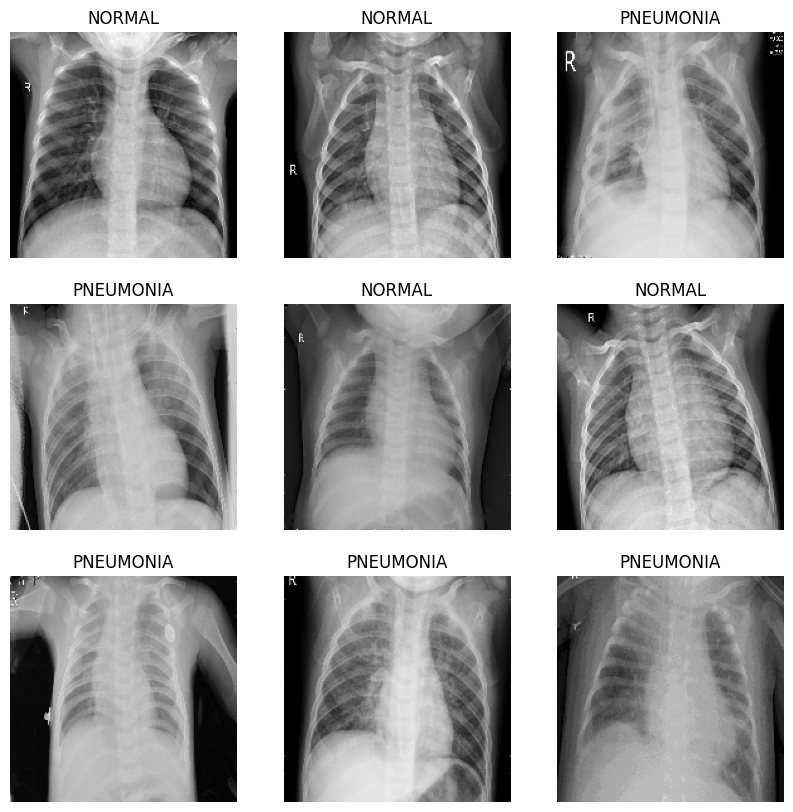

In [9]:
import numpy as np

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    idx = np.random.choice(len(images), 9, replace=False)

    for i, j in enumerate(idx):
        plt.subplot(3,3,i+1)
        plt.imshow(images[j].numpy().astype("uint8"))
        plt.title(class_names[labels[j]])
        plt.axis("off")

plt.show()

In [10]:
all_images = []
all_labels = []

for images, labels in train_ds:
    for img, label in zip(images, labels):
        all_images.append(img.numpy())
        all_labels.append(label.numpy())

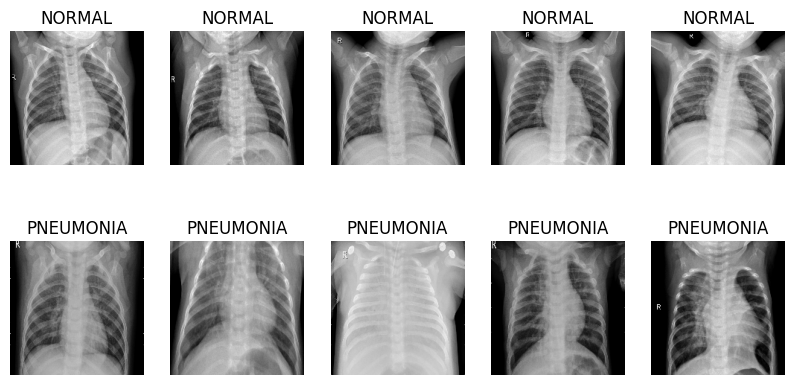

In [11]:
normal_images = []
pneumonia_images = []

for img, label in zip(all_images, all_labels):
    if class_names[label] == "NORMAL":
        normal_images.append(img)
    else:
        pneumonia_images.append(img)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(normal_images[np.random.randint(len(normal_images))].astype("uint8"))
    plt.title("NORMAL")
    plt.axis("off")

for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(pneumonia_images[np.random.randint(len(pneumonia_images))].astype("uint8"))
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.show()

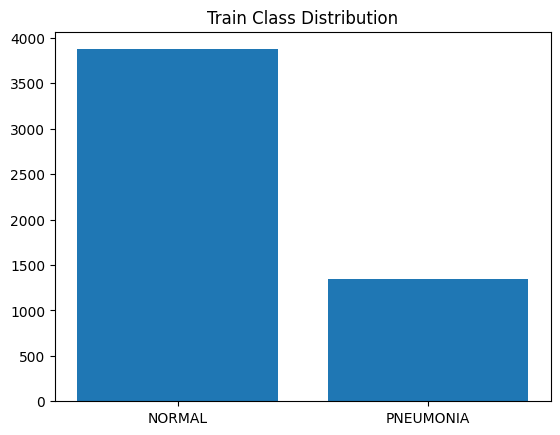

In [12]:
def count_classes(dataset):
    counts = {}
    for _, labels in dataset:
        for label in labels.numpy():
            counts[label] = counts.get(label, 0) + 1
    return counts

train_counts = count_classes(train_ds)

plt.bar(class_names, train_counts.values())
plt.title("Train Class Distribution")
plt.show()

In [13]:
all_labels_flat = []

for _, labels in train_ds:
    all_labels_flat.extend(labels.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels_flat),
    y=all_labels_flat
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [14]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [16]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(180,180,3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=2),
    keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.5195 - loss: 0.9373

163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 818ms/step - accuracy: 0.6227 - loss: 0.6524 - val_accuracy: 0.8125 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.8303 - loss: 0.3809

163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 807ms/step - accuracy: 0.8388 - loss: 0.3600 - val_accuracy: 0.8125 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 809ms/step - accuracy: 0.8549 - loss: 0.3275 - val_accuracy: 0.7500 - val_loss: 0.5989 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.8932 - loss: 0.2595

163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 807ms/step - accuracy: 0.9032 - loss: 0.2461 - val_accuracy: 0.8125 - val_loss: 0.3896 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9053 - loss: 0.2244 - val_accuracy: 0.8125 - val_loss: 0.4586 - learning_rate: 0.0010
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 800ms/step - accuracy: 0.9300 - loss: 0.1875 - val_accuracy: 0.8750 - val_loss: 0.4665 - learning_rate: 0.0010
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 802ms/step - accuracy: 0.9340 - loss: 0.1681 - val_accuracy: 0.7500 - val_loss: 0.4102 - learning_rate: 1.0000e-04
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9467 - loss: 0.1449 - val_accuracy: 0.8750 - val_loss: 0.4657 - learning_rate: 1.0000e-04
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.9371 - loss: 0.1646

163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 801ms/step - accuracy: 0.9433 - loss: 0.1497 - val_accuracy: 0.8750 - val_loss: 0.3813 - learning_rate: 1.0000e-05
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 803ms/step - accuracy: 0.9429 - loss: 0.1452 - val_accuracy: 0.8750 - val_loss: 0.3893 - learning_rate: 1.0000e-05
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 807ms/step - accuracy: 0.9440 - loss: 0.1493 - val_accuracy: 0.8125 - val_loss: 0.3864 - learning_rate: 1.0000e-05
Epoch 12/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 804ms/step - accuracy: 0.9494 - loss: 0.1445 - val_accuracy: 0.8750 - val_loss: 0.3868 - learning_rate: 1.0000e-06
Epoch 13/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 802ms/step - accuracy: 0.9452 - loss: 0.1483 - val_accuracy: 0.8125 - val_loss: 0.3861 - learning_rate: 1.0000e-06
Epoch 14/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 780ms/step - accuracy: 0.9427 - loss: 0.1394 - val_accuracy: 0.8125 - val_loss: 0.3860 - learning_rate: 1.0000e-07


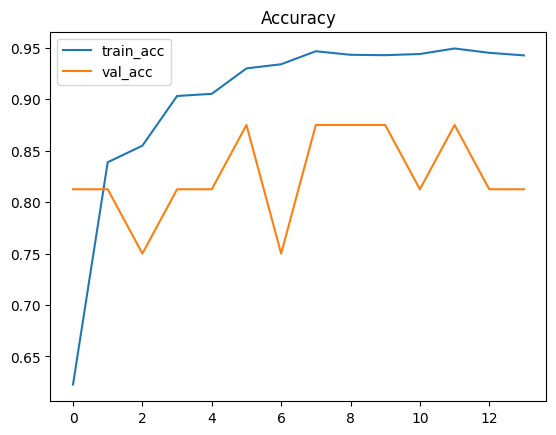

In [21]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


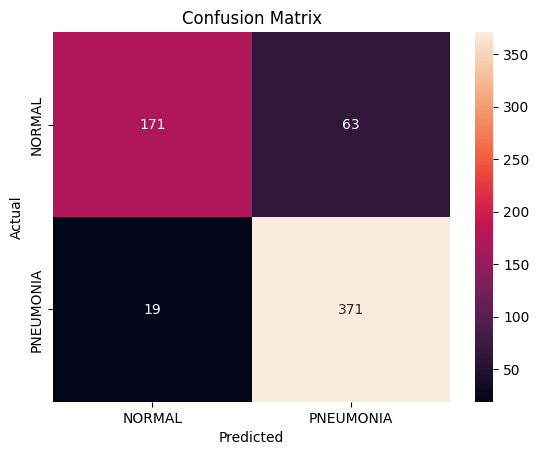

In [23]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       0.90      0.73      0.81       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.85       624
weighted avg       0.87      0.87      0.87       624



In [25]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.8686 - loss: 0.2993
✅ Test Accuracy: 0.8686
✅ Test Loss: 0.2993


In [26]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [27]:
model.save("model.h5")

In [28]:
model.save("pneumonia_model.h5")

In [29]:
model.save("pneumonia_model.keras")

In [30]:
train_ds_temp = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(180,180),
    batch_size=32
)

class_names = train_ds_temp.class_names
print(class_names)

Found 5216 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


In [31]:
import json

# If class_names is still available
print(class_names)

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("✅ class_names.json saved")

['NORMAL', 'PNEUMONIA']
✅ class_names.json saved


In [32]:
model.save("clean_model.h5", include_optimizer=False)